In [9]:
"""
PD Gait Classification - Literature-Based Features
Based on standard gait analysis papers
- Temporal features: stance, swing, stride, step durations
- Kinetic features: heel strike, toe off forces
- 10-fold cross-validation
- ML: SVM, KNN, Random Forest, XGBoost, Feedforward NN
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
import os

# ML
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================================
# DATA LOADING
# ============================================================================

def load_data(data_dir=r'C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data'):
    """Load gait data"""
    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                               sep='\t', on_bad_lines='skip')
    
    subjects = []
    labels = []
    
    for idx, row in demographics.iterrows():
        subject_id = row['ID']
        group = row['Group']
        filepath = f"{data_dir}/{subject_id}_01.txt"
        
        if os.path.exists(filepath):
            try:
                data = pd.read_csv(filepath, sep='\t', header=None).values
                if len(data) > 500:
                    subjects.append({'id': subject_id, 'data': data})
                    labels.append(0 if group == 1 else 1)  # 0=PD, 1=Control
            except:
                continue
    
    print(f"Loaded {len(subjects)} subjects: {sum(labels)} Controls, {len(labels)-sum(labels)} PD")
    return subjects, np.array(labels)

# ============================================================================
# GAIT EVENT DETECTION
# ============================================================================

def detect_gait_events(force_signal, fs=100):
    """
    Detect heel strikes and toe-offs
    Returns: heel_strike_times, toe_off_times (in seconds)
    """
    threshold = 0.15 * np.max(force_signal)
    
    # Stance: force > threshold
    stance = force_signal > threshold
    stance_diff = np.diff(stance.astype(int))
    
    # Heel strikes: 0->1 transitions
    heel_strikes = np.where(stance_diff == 1)[0] / fs
    
    # Toe offs: 1->0 transitions  
    toe_offs = np.where(stance_diff == -1)[0] / fs
    
    return heel_strikes, toe_offs

# ============================================================================
# FEATURE EXTRACTION (Literature-Based)
# ============================================================================

def extract_gait_features(subject_data):
    """
    Extract 12 most important gait features from literature
    Focus on mean values and key ratios only
    """
    data = subject_data['data']
    fs = 100
    duration = len(data) / fs
    
    # Force signals
    left_force = data[:, 17]
    right_force = data[:, 18]
    
    # Detect events
    left_hs, left_to = detect_gait_events(left_force, fs)
    right_hs, right_to = detect_gait_events(right_force, fs)
    
    features = {}
    
    # ========================================================================
    # TEMPORAL FEATURES (6 features)
    # ========================================================================
    
    # 1. Stance time (mean only)
    left_stance = []
    for hs in left_hs:
        matching_to = left_to[left_to > hs]
        if len(matching_to) > 0:
            left_stance.append(matching_to[0] - hs)
    
    right_stance = []
    for hs in right_hs:
        matching_to = right_to[right_to > hs]
        if len(matching_to) > 0:
            right_stance.append(matching_to[0] - hs)
    
    features['stance_time'] = np.mean(left_stance + right_stance) if len(left_stance + right_stance) > 0 else 0
    
    # 2. Swing time (mean only)
    left_swing = []
    for i in range(len(left_to)):
        next_hs = left_hs[left_hs > left_to[i]]
        if len(next_hs) > 0:
            left_swing.append(next_hs[0] - left_to[i])
    
    right_swing = []
    for i in range(len(right_to)):
        next_hs = right_hs[right_hs > right_to[i]]
        if len(next_hs) > 0:
            right_swing.append(next_hs[0] - right_to[i])
    
    features['swing_time'] = np.mean(left_swing + right_swing) if len(left_swing + right_swing) > 0 else 0
    
    # 3. Stride time (mean only)
    left_stride = np.diff(left_hs)
    right_stride = np.diff(right_hs)
    features['stride_time'] = np.mean(list(left_stride) + list(right_stride)) if len(left_stride) + len(right_stride) > 0 else 0
    
    # 4. Stride time variability (CV)
    all_strides = list(left_stride) + list(right_stride)
    if len(all_strides) > 0:
        features['stride_variability'] = np.std(all_strides) / (np.mean(all_strides) + 1e-10)
    else:
        features['stride_variability'] = 0
    
    # 5. Step time
    all_contacts = sorted(list(left_hs) + list(right_hs))
    if len(all_contacts) > 1:
        step_times = np.diff(all_contacts)
        features['step_time'] = np.mean(step_times)
    else:
        features['step_time'] = 0
    
    # 6. Cadence (steps per minute)
    total_steps = len(left_hs) + len(right_hs)
    features['cadence'] = (total_steps / duration) * 60 if duration > 0 else 0
    
    # ========================================================================
    # KINETIC FEATURES (2 features)
    # ========================================================================
    
    # 7. Peak force
    features['peak_force'] = (np.max(left_force) + np.max(right_force)) / 2
    
    # 8. Mean force
    features['mean_force'] = (np.mean(left_force) + np.mean(right_force)) / 2
    
    # ========================================================================
    # BILATERAL FEATURES (4 features)
    # ========================================================================
    
    # 9. Swing-to-stance ratio
    if features['stance_time'] > 0:
        features['swing_stance_ratio'] = features['swing_time'] / features['stance_time']
    else:
        features['swing_stance_ratio'] = 0
    
    # 10. Double support percentage
    dls_time = 0
    for left_start, left_end in zip(left_hs, left_to):
        for right_start, right_end in zip(right_hs, right_to):
            overlap_start = max(left_start, right_start)
            overlap_end = min(left_end, right_end)
            if overlap_start < overlap_end:
                dls_time += (overlap_end - overlap_start)
    features['double_support_pct'] = (dls_time / duration) * 100 if duration > 0 else 0
    
    # 11. Stride asymmetry
    if len(left_stride) > 0 and len(right_stride) > 0:
        left_mean = np.mean(left_stride)
        right_mean = np.mean(right_stride)
        features['stride_asymmetry'] = abs(left_mean - right_mean) / ((left_mean + right_mean) / 2 + 1e-10)
    else:
        features['stride_asymmetry'] = 0
    
    # 12. Stance asymmetry
    if len(left_stance) > 0 and len(right_stance) > 0:
        left_mean = np.mean(left_stance)
        right_mean = np.mean(right_stance)
        features['stance_asymmetry'] = abs(left_mean - right_mean) / ((left_mean + right_mean) / 2 + 1e-10)
    else:
        features['stance_asymmetry'] = 0
    
    return features

def create_feature_matrix(subjects):
    """Extract features for all subjects"""
    print("\nExtracting literature-based gait features...")
    
    feature_list = []
    for i, subject in enumerate(subjects):
        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(subjects)}")
        features = extract_gait_features(subject)
        features['subject_id'] = subject['id']
        feature_list.append(features)
    
    df = pd.DataFrame(feature_list)
    print(f"Extracted 12 features from {len(df)} subjects")
    
    return df

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

def statistical_analysis(df_features, labels, output_dir='outputs'):
    """Statistical analysis"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    pd_mask = labels == 0
    ctrl_mask = labels == 1
    
    feature_cols = [c for c in df_features.columns if c != 'subject_id']
    
    results = []
    for feat in feature_cols:
        pd_data = df_features.loc[pd_mask, feat].values
        ctrl_data = df_features.loc[ctrl_mask, feat].values
        
        pd_data = pd_data[np.isfinite(pd_data)]
        ctrl_data = ctrl_data[np.isfinite(ctrl_data)]
        
        if len(pd_data) > 0 and len(ctrl_data) > 0:
            u_stat, p_value = stats.mannwhitneyu(pd_data, ctrl_data)
            
            cohens_d = (np.mean(pd_data) - np.mean(ctrl_data)) / \
                       np.sqrt((np.std(pd_data)**2 + np.std(ctrl_data)**2) / 2)
            
            results.append({
                'feature': feat,
                'pd_mean': np.mean(pd_data),
                'pd_std': np.std(pd_data),
                'ctrl_mean': np.mean(ctrl_data),
                'ctrl_std': np.std(ctrl_data),
                'p_value': p_value,
                'cohens_d': cohens_d
            })
    
    df_stats = pd.DataFrame(results).sort_values('p_value')
    df_stats.to_csv(f'{output_dir}/statistical_analysis.csv', index=False)
    
    print("\nTop 10 Discriminative Features:")
    print(df_stats.head(10)[['feature', 'p_value', 'cohens_d']].to_string(index=False))
    
    print(f"\nSaved: {output_dir}/statistical_analysis.csv")
    
    return df_stats

# ============================================================================
# ML MODELS - 10-FOLD CV
# ============================================================================

def train_ml_models(X, y, output_dir='outputs'):
    """Train with 10-fold CV"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("MACHINE LEARNING - 10-FOLD CV")
    print("="*60)
    
    models = {
        'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
        'Feedforward NN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    }
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = []
    
    for model_name, model in models.items():
        print(f"\n{'='*40}")
        print(f"{model_name}")
        print(f"{'='*40}")
        
        fold_accs = []
        fold_f1s = []
        all_y_true = []
        all_y_pred = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='macro')
            fold_accs.append(acc)
            fold_f1s.append(f1)
            
            all_y_true.extend(y_val)
            all_y_pred.extend(y_pred)
            
            print(f"  Fold {fold:2d}: Acc={acc*100:.2f}%  F1={f1*100:.2f}%")
        
        mean_acc = np.mean(fold_accs)
        std_acc = np.std(fold_accs)
        mean_f1 = np.mean(fold_f1s)
        std_f1 = np.std(fold_f1s)
        
        print(f"\n  Mean Acc: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
        print(f"  Mean F1 : {mean_f1*100:.2f}% ± {std_f1*100:.2f}%")
        
        results.append({
            'model': model_name,
            'mean_accuracy': mean_acc,
            'std_accuracy': std_acc,
            'mean_f1': mean_f1,
            'std_f1': std_f1
        })
        
        # Confusion matrix
        cm = confusion_matrix(all_y_true, all_y_pred)
        
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['PD', 'Control'], yticklabels=['PD', 'Control'])
        plt.title(f'{model_name} - 10-Fold CV', fontsize=12, fontweight='bold')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/cm_{model_name.replace(" ", "_")}.png', dpi=300)
        plt.close()
        
        # Report
        report = classification_report(all_y_true, all_y_pred, target_names=['PD', 'Control'])
        with open(f'{output_dir}/report_{model_name.replace(" ", "_")}.txt', 'w') as f:
            f.write(f"{model_name} - 10-Fold CV\n{'='*50}\n\n{report}")
    
    # Summary
    df_results = pd.DataFrame(results).sort_values('mean_accuracy', ascending=False)
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(df_results.to_string(index=False))
    
    df_results.to_csv(f'{output_dir}/model_comparison.csv', index=False)
    
    # Plot - Accuracy
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    x = range(len(df_results))
    
    axes[0].bar(x, df_results['mean_accuracy']*100, yerr=df_results['std_accuracy']*100,
                capsize=5, alpha=0.7, color='steelblue')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_results['model'], rotation=45, ha='right')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Accuracy - 10-Fold CV', fontsize=13, fontweight='bold')
    axes[0].set_ylim([0, 100])
    axes[0].grid(axis='y', alpha=0.3)
    
    # Plot - F1
    axes[1].bar(x, df_results['mean_f1']*100, yerr=df_results['std_f1']*100,
                capsize=5, alpha=0.7, color='darkorange')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_results['model'], rotation=45, ha='right')
    axes[1].set_ylabel('F1 Score (%)')
    axes[1].set_title('Macro F1 - 10-Fold CV', fontsize=13, fontweight='bold')
    axes[1].set_ylim([0, 100])
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/model_comparison.png', dpi=300)
    plt.close()
    
    print(f"\nResults saved to: {output_dir}/")

# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    print("="*60)
    print("PD GAIT: LITERATURE-BASED FEATURES + 10-FOLD CV")
    print("="*60)
    
    subjects, labels = load_data()
    
    if len(subjects) < 10:
        print("\n Warning: Need >= 10 subjects")
    else:
        # Extract
        df_features = create_feature_matrix(subjects)
        
        # Stats
        df_stats = statistical_analysis(df_features, labels)
        
        # ML
        X = df_features.drop('subject_id', axis=1).values
        y = labels
        
        train_ml_models(X, y)
    
    print("\nComplete!")

PD GAIT: LITERATURE-BASED FEATURES + 10-FOLD CV
Loaded 158 subjects: 65 Controls, 93 PD

Extracting literature-based gait features...
  Processed 20/158
  Processed 40/158
  Processed 60/158
  Processed 80/158
  Processed 100/158
  Processed 120/158
  Processed 140/158
Extracted 12 features from 158 subjects

STATISTICAL ANALYSIS

Top 10 Discriminative Features:
           feature      p_value  cohens_d
swing_stance_ratio 9.803522e-07 -0.842204
  stance_asymmetry 3.699636e-03  0.266113
       stance_time 1.015351e-02  0.461137
stride_variability 2.173594e-02  0.360058
         step_time 1.007414e-01  0.298681
       stride_time 1.037082e-01  0.299799
           cadence 1.549295e-01 -0.261317
        mean_force 3.063444e-01  0.104249
        swing_time 5.236164e-01 -0.102433
  stride_asymmetry 6.857886e-01 -0.019666

Saved: outputs/statistical_analysis.csv

MACHINE LEARNING - 10-FOLD CV

SVM (RBF)
  Fold  1: Acc=81.25%  F1=79.22%
  Fold  2: Acc=81.25%  F1=78.18%
  Fold  3: Acc=59.38%  F

In [4]:
def load_data_debug(data_dir=r'C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data'):
    
    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                               sep='\t', on_bad_lines='skip')
    demographics = demographics.dropna(subset=['ID'])

    total_in_demographics = len(demographics)
    
    no_file_pd, no_file_ctrl         = 0, 0
    dropped_pd, dropped_ctrl         = 0, 0
    loaded_pd, loaded_ctrl           = 0, 0
    dropped_subjects                 = []   # (id, group, n_samples)

    for _, row in demographics.iterrows():
        subject_id = row['ID']
        group      = row['Group']
        label      = 'PD' if group == 1 else 'Control'
        filepath   = f"{data_dir}/{subject_id}_01.txt"

        if not os.path.exists(filepath):
            if group == 1: no_file_pd   += 1
            else:          no_file_ctrl += 1
            continue

        try:
            data = pd.read_csv(filepath, sep='\t', header=None).values
            n    = len(data)

            if n <= 500:                          # ← the filter
                dropped_subjects.append((subject_id, label, n))
                if group == 1: dropped_pd   += 1
                else:          dropped_ctrl += 1
            else:
                if group == 1: loaded_pd   += 1
                else:          loaded_ctrl += 1

        except Exception as e:
            print(f"  [ERROR] {subject_id}: {e}")

    # ── Report ──────────────────────────────────────────────
    print("=" * 55)
    print("DATA LOADING DEBUG REPORT")
    print("=" * 55)
    print(f"Total rows in demographics       : {total_in_demographics}")
    print()
    print(f"{'':30s}  {'PD':>6}  {'Control':>8}")
    print(f"  No data file found             : {no_file_pd:>6}  {no_file_ctrl:>8}")
    print(f"  Dropped (<=500 samples)        : {dropped_pd:>6}  {dropped_ctrl:>8}")
    print(f"  Loaded                         : {loaded_pd:>6}  {loaded_ctrl:>8}")
    print(f"  Total loaded                   : {loaded_pd + loaded_ctrl}")
    print()

    if dropped_subjects:
        print(f"Dropped subject details (n <= 500 samples):")
        print(f"  {'ID':<12} {'Group':<10} {'Samples':>8}  {'Duration(s)':>12}")
        print(f"  {'-'*46}")
        for sid, grp, n in sorted(dropped_subjects, key=lambda x: x[2]):
            print(f"  {sid:<12} {grp:<10} {n:>8}  {n/100:>11.1f}s")

if __name__ == '__main__':
    load_data_debug()

DATA LOADING DEBUG REPORT
Total rows in demographics       : 159

                                    PD   Control
  No data file found             :      0         1
  Dropped (<=500 samples)        :      0         0
  Loaded                         :     93        65
  Total loaded                   : 158



In [ ]:
"""
PD Gait Classification - Literature-Based Features
Based on standard gait analysis papers
- Temporal features: stance, swing, stride, step durations
- Kinetic features: heel strike, toe off forces
- 10-fold cross-validation
- ML: SVM, KNN, Random Forest, XGBoost, Feedforward NN
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
import os

# ML
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================================
# DATA LOADING
# ============================================================================

def load_data(data_dir=r'C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data'):
    """Load gait data"""
    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                               sep='\t', on_bad_lines='skip')
    
    subjects = []
    labels = []
    
    for idx, row in demographics.iterrows():
        subject_id = row['ID']
        group = row['Group']
        filepath = f"{data_dir}/{subject_id}_01.txt"
        
        if os.path.exists(filepath):
            try:
                data = pd.read_csv(filepath, sep='\t', header=None).values
                if len(data) > 500:
                    subjects.append({'id': subject_id, 'data': data})
                    labels.append(0 if group == 1 else 1)  # 0=PD, 1=Control
            except:
                continue
    
    print(f"Loaded {len(subjects)} subjects: {sum(labels)} Controls, {len(labels)-sum(labels)} PD")
    return subjects, np.array(labels)

# ============================================================================
# GAIT EVENT DETECTION
# ============================================================================

def detect_gait_events(force_signal, fs=100):
    """
    Detect heel strikes and toe-offs
    Returns: heel_strike_times, toe_off_times (in seconds)
    """
    threshold = 0.15 * np.max(force_signal)
    
    # Stance: force > threshold
    stance = force_signal > threshold
    stance_diff = np.diff(stance.astype(int))
    
    # Heel strikes: 0→1 transitions
    heel_strikes = np.where(stance_diff == 1)[0] / fs
    
    # Toe offs: 1→0 transitions  
    toe_offs = np.where(stance_diff == -1)[0] / fs
    
    return heel_strikes, toe_offs

# ============================================================================
# FEATURE EXTRACTION (Literature-Based)
# ============================================================================

def extract_gait_features(subject_data):
    """
    Extract 12 most important gait features from literature
    Focus on mean values and key ratios only
    """
    data = subject_data['data']
    fs = 100
    duration = len(data) / fs
    
    # Force signals
    left_force = data[:, 17]
    right_force = data[:, 18]
    
    # Detect events
    left_hs, left_to = detect_gait_events(left_force, fs)
    right_hs, right_to = detect_gait_events(right_force, fs)
    
    features = {}
    
    # ========================================================================
    # TEMPORAL FEATURES (6 features)
    # ========================================================================
    
    # 1. Stance time (mean only)
    left_stance = []
    for hs in left_hs:
        matching_to = left_to[left_to > hs]
        if len(matching_to) > 0:
            left_stance.append(matching_to[0] - hs)
    
    right_stance = []
    for hs in right_hs:
        matching_to = right_to[right_to > hs]
        if len(matching_to) > 0:
            right_stance.append(matching_to[0] - hs)
    
    features['stance_time'] = np.mean(left_stance + right_stance) if len(left_stance + right_stance) > 0 else 0
    
    # 2. Swing time (mean only)
    left_swing = []
    for i in range(len(left_to)):
        next_hs = left_hs[left_hs > left_to[i]]
        if len(next_hs) > 0:
            left_swing.append(next_hs[0] - left_to[i])
    
    right_swing = []
    for i in range(len(right_to)):
        next_hs = right_hs[right_hs > right_to[i]]
        if len(next_hs) > 0:
            right_swing.append(next_hs[0] - right_to[i])
    
    features['swing_time'] = np.mean(left_swing + right_swing) if len(left_swing + right_swing) > 0 else 0
    
    # 3. Stride time (mean only)
    left_stride = np.diff(left_hs)
    right_stride = np.diff(right_hs)
    features['stride_time'] = np.mean(list(left_stride) + list(right_stride)) if len(left_stride) + len(right_stride) > 0 else 0
    
    # 4. Stride time variability (CV)
    all_strides = list(left_stride) + list(right_stride)
    if len(all_strides) > 0:
        features['stride_variability'] = np.std(all_strides) / (np.mean(all_strides) + 1e-10)
    else:
        features['stride_variability'] = 0
    
    # 5. Step time
    all_contacts = sorted(list(left_hs) + list(right_hs))
    if len(all_contacts) > 1:
        step_times = np.diff(all_contacts)
        features['step_time'] = np.mean(step_times)
    else:
        features['step_time'] = 0
    
    # 6. Cadence (steps per minute)
    total_steps = len(left_hs) + len(right_hs)
    features['cadence'] = (total_steps / duration) * 60 if duration > 0 else 0
    
    # ========================================================================
    # KINETIC FEATURES (2 features)
    # ========================================================================
    
    # 7. Peak force
    features['peak_force'] = (np.max(left_force) + np.max(right_force)) / 2
    
    # 8. Mean force
    features['mean_force'] = (np.mean(left_force) + np.mean(right_force)) / 2
    
    # ========================================================================
    # BILATERAL FEATURES (4 features)
    # ========================================================================
    
    # 9. Swing-to-stance ratio
    if features['stance_time'] > 0:
        features['swing_stance_ratio'] = features['swing_time'] / features['stance_time']
    else:
        features['swing_stance_ratio'] = 0
    
    # 10. Double support percentage
    dls_time = 0
    for left_start, left_end in zip(left_hs, left_to):
        for right_start, right_end in zip(right_hs, right_to):
            overlap_start = max(left_start, right_start)
            overlap_end = min(left_end, right_end)
            if overlap_start < overlap_end:
                dls_time += (overlap_end - overlap_start)
    features['double_support_pct'] = (dls_time / duration) * 100 if duration > 0 else 0
    
    # 11. Stride asymmetry
    if len(left_stride) > 0 and len(right_stride) > 0:
        left_mean = np.mean(left_stride)
        right_mean = np.mean(right_stride)
        features['stride_asymmetry'] = abs(left_mean - right_mean) / ((left_mean + right_mean) / 2 + 1e-10)
    else:
        features['stride_asymmetry'] = 0
    
    # 12. Stance asymmetry
    if len(left_stance) > 0 and len(right_stance) > 0:
        left_mean = np.mean(left_stance)
        right_mean = np.mean(right_stance)
        features['stance_asymmetry'] = abs(left_mean - right_mean) / ((left_mean + right_mean) / 2 + 1e-10)
    else:
        features['stance_asymmetry'] = 0
    
    return features

def create_feature_matrix(subjects):
    """Extract features for all subjects"""
    print("\nExtracting literature-based gait features...")
    
    feature_list = []
    for i, subject in enumerate(subjects):
        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(subjects)}")
        features = extract_gait_features(subject)
        features['subject_id'] = subject['id']
        feature_list.append(features)
    
    df = pd.DataFrame(feature_list)
    print(f"✓ Extracted 12 features from {len(df)} subjects")
    
    return df

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

def statistical_analysis(df_features, labels, output_dir='outputs'):
    """Statistical analysis"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    pd_mask = labels == 0
    ctrl_mask = labels == 1
    
    feature_cols = [c for c in df_features.columns if c != 'subject_id']
    
    results = []
    for feat in feature_cols:
        pd_data = df_features.loc[pd_mask, feat].values
        ctrl_data = df_features.loc[ctrl_mask, feat].values
        
        pd_data = pd_data[np.isfinite(pd_data)]
        ctrl_data = ctrl_data[np.isfinite(ctrl_data)]
        
        if len(pd_data) > 0 and len(ctrl_data) > 0:
            u_stat, p_value = stats.mannwhitneyu(pd_data, ctrl_data)
            
            cohens_d = (np.mean(pd_data) - np.mean(ctrl_data)) / \
                       np.sqrt((np.std(pd_data)**2 + np.std(ctrl_data)**2) / 2)
            
            results.append({
                'feature': feat,
                'pd_mean': np.mean(pd_data),
                'pd_std': np.std(pd_data),
                'ctrl_mean': np.mean(ctrl_data),
                'ctrl_std': np.std(ctrl_data),
                'p_value': p_value,
                'cohens_d': cohens_d
            })
    
    df_stats = pd.DataFrame(results).sort_values('p_value')
    df_stats.to_csv(f'{output_dir}/statistical_analysis.csv', index=False)
    
    print("\nTop 10 Discriminative Features:")
    print(df_stats.head(10)[['feature', 'p_value', 'cohens_d']].to_string(index=False))
    
    print(f"\n✓ Saved: {output_dir}/statistical_analysis.csv")
    
    return df_stats

# ============================================================================
# ML MODELS - 5-FOLD CV
# ============================================================================

def train_ml_models(X, y, output_dir='outputs'):
    """Train with 10-fold CV"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("MACHINE LEARNING - 10-FOLD CV")
    print("="*60)
    
    models = {
        'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
        'Feedforward NN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    }
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = []
    
    for model_name, model in models.items():
        print(f"\n{'='*40}")
        print(f"{model_name}")
        print(f"{'='*40}")
        
        fold_accs = []
        all_y_true = []
        all_y_pred = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            
            acc = accuracy_score(y_val, y_pred)
            fold_accs.append(acc)
            
            all_y_true.extend(y_val)
            all_y_pred.extend(y_pred)
            
            print(f"  Fold {fold:2d}: {acc*100:.2f}%")
        
        mean_acc = np.mean(fold_accs)
        std_acc = np.std(fold_accs)
        
        print(f"\n  Mean: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
        
        results.append({
            'model': model_name,
            'mean_accuracy': mean_acc,
            'std_accuracy': std_acc
        })
        
        # Confusion matrix
        cm = confusion_matrix(all_y_true, all_y_pred)
        
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['PD', 'Control'], yticklabels=['PD', 'Control'])
        plt.title(f'{model_name} - 10-Fold CV', fontsize=12, fontweight='bold')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/cm_{model_name.replace(" ", "_")}.png', dpi=300)
        plt.close()
        
        # Report
        report = classification_report(all_y_true, all_y_pred, target_names=['PD', 'Control'])
        with open(f'{output_dir}/report_{model_name.replace(" ", "_")}.txt', 'w') as f:
            f.write(f"{model_name} - 10-Fold CV\n{'='*50}\n\n{report}")
    
    # Summary
    df_results = pd.DataFrame(results).sort_values('mean_accuracy', ascending=False)
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(df_results.to_string(index=False))
    
    df_results.to_csv(f'{output_dir}/model_comparison.csv', index=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    x = range(len(df_results))
    plt.bar(x, df_results['mean_accuracy']*100, yerr=df_results['std_accuracy']*100,
            capsize=5, alpha=0.7, color='steelblue')
    plt.xticks(x, df_results['model'], rotation=45, ha='right')
    plt.ylabel('Accuracy (%)')
    plt.title('Model Comparison - 10-Fold CV', fontsize=14, fontweight='bold')
    plt.ylim([0, 100])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/model_comparison.png', dpi=300)
    plt.close()
    
    print(f"\n✓ Results: {output_dir}/")

# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    print("="*60)
    print("PD GAIT: LITERATURE-BASED FEATURES + 10-FOLD CV")
    print("="*60)
    
    subjects, labels = load_data()
    
    if len(subjects) < 10:
        print("\n⚠ Need ≥10 subjects")
    else:
        # Extract
        df_features = create_feature_matrix(subjects)
        
        # Stats
        df_stats = statistical_analysis(df_features, labels)
        
        # ML
        X = df_features.drop('subject_id', axis=1).values
        y = labels
        
        train_ml_models(X, y)
    
    print("\n✓ Complete!")

PD GAIT: LITERATURE-BASED FEATURES + 10-FOLD CV
Loaded 158 subjects: 65 Controls, 93 PD

Extracting literature-based gait features...
  Processed 20/158
  Processed 40/158
  Processed 60/158
  Processed 80/158
  Processed 100/158
  Processed 120/158
  Processed 140/158
✓ Extracted 12 features from 158 subjects

STATISTICAL ANALYSIS

Top 10 Discriminative Features:
           feature      p_value  cohens_d
swing_stance_ratio 9.803522e-07 -0.842204
  stance_asymmetry 3.699636e-03  0.266113
       stance_time 1.015351e-02  0.461137
stride_variability 2.173594e-02  0.360058
         step_time 1.007414e-01  0.298681
       stride_time 1.037082e-01  0.299799
           cadence 1.549295e-01 -0.261317
        mean_force 3.063444e-01  0.104249
        swing_time 5.236164e-01 -0.102433
  stride_asymmetry 6.857886e-01 -0.019666

✓ Saved: outputs/statistical_analysis.csv

MACHINE LEARNING - 10-FOLD CV

SVM (RBF)
  Fold  1: 81.25%
  Fold  2: 81.25%
  Fold  3: 59.38%
  Fold  4: 67.74%
  Fold  5: 64.

In [ ]:
"""
PD Gait Classification - Literature-Based Features
Based on standard gait analysis papers
- Temporal features: stance, swing, stride, step durations
- Kinetic features: heel strike, toe off forces
- 10-fold cross-validation
- ML: SVM, KNN, Random Forest, XGBoost, Feedforward NN
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
import os

# ML
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             accuracy_score, f1_score)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================================
# DATA LOADING
# ============================================================================

def load_data(data_dir=r'C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data',
              start_sample=0, n_samples=6000, min_samples=500):
    """
    Load gait data.
    - Drops recordings shorter than `min_samples`.
    - Takes `n_samples` starting from `start_sample` (default: first 30s at 100 Hz).
    """
    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                               sep='\t', on_bad_lines='skip')
    
    subjects = []
    labels = []
    skipped_short = 0
    skipped_error = 0
    skipped_missing = 0
    
    for idx, row in demographics.iterrows():
        subject_id = row['ID']
        group = row['Group']
        filepath = f"{data_dir}/{subject_id}_01.txt"
        
        if not os.path.exists(filepath):
            skipped_missing += 1
            continue
        
        try:
            data = pd.read_csv(filepath, sep='\t', header=None).values
        except Exception:
            skipped_error += 1
            continue
        
        # Drop recordings that are too short
        if len(data) < min_samples:
            skipped_short += 1
            continue
        
        # Take the requested window; if shorter than n_samples, take what's available
        end_sample = start_sample + n_samples
        if len(data) < end_sample:
            data = data[start_sample:]  # take from start_sample to end
        else:
            data = data[start_sample:end_sample]
        
        # Final safety check (in case start_sample pushed us below min)
        if len(data) < min_samples:
            skipped_short += 1
            continue
        
        subjects.append({'id': subject_id, 'data': data})
        labels.append(0 if group == 1 else 1)  # 0=PD, 1=Control
    
    labels = np.array(labels)
    n_pd = int(np.sum(labels == 0))
    n_ctrl = int(np.sum(labels == 1))
    
    print("\n" + "="*60)
    print("DATA LOADING SUMMARY")
    print("="*60)
    print(f"Window:          samples {start_sample} to {start_sample + n_samples} "
          f"({n_samples/100:.1f} sec at 100 Hz)")
    print(f"Min length req:  {min_samples} samples ({min_samples/100:.1f} sec)")
    print(f"")
    print(f"Loaded:          {len(subjects)} subjects")
    print(f"  PD:            {n_pd}")
    print(f"  Control:       {n_ctrl}")
    print(f"")
    print(f"Skipped (too short):  {skipped_short}")
    print(f"Skipped (read error): {skipped_error}")
    print(f"Skipped (file missing): {skipped_missing}")
    print("="*60)
    
    return subjects, labels

# ============================================================================
# GAIT EVENT DETECTION
# ============================================================================

def detect_gait_events(force_signal, fs=100):
    """
    Detect heel strikes and toe-offs
    Returns: heel_strike_times, toe_off_times (in seconds)
    """
    threshold = 0.15 * np.max(force_signal)
    
    # Stance: force > threshold
    stance = force_signal > threshold
    stance_diff = np.diff(stance.astype(int))
    
    # Heel strikes: 0→1 transitions
    heel_strikes = np.where(stance_diff == 1)[0] / fs
    
    # Toe offs: 1→0 transitions  
    toe_offs = np.where(stance_diff == -1)[0] / fs
    
    return heel_strikes, toe_offs

# ============================================================================
# FEATURE EXTRACTION (Literature-Based)
# ============================================================================

def extract_gait_features(subject_data):
    """
    Extract 12 most important gait features from literature
    Focus on mean values and key ratios only
    """
    data = subject_data['data']
    fs = 100
    duration = len(data) / fs
    
    # Force signals
    left_force = data[:, 17]
    right_force = data[:, 18]
    
    # Detect events
    left_hs, left_to = detect_gait_events(left_force, fs)
    right_hs, right_to = detect_gait_events(right_force, fs)
    
    features = {}
    
    # ========================================================================
    # TEMPORAL FEATURES (6 features)
    # ========================================================================
    
    # 1. Stance time (mean only)
    left_stance = []
    for hs in left_hs:
        matching_to = left_to[left_to > hs]
        if len(matching_to) > 0:
            left_stance.append(matching_to[0] - hs)
    
    right_stance = []
    for hs in right_hs:
        matching_to = right_to[right_to > hs]
        if len(matching_to) > 0:
            right_stance.append(matching_to[0] - hs)
    
    features['stance_time'] = np.mean(left_stance + right_stance) if len(left_stance + right_stance) > 0 else 0
    
    # 2. Swing time (mean only)
    left_swing = []
    for i in range(len(left_to)):
        next_hs = left_hs[left_hs > left_to[i]]
        if len(next_hs) > 0:
            left_swing.append(next_hs[0] - left_to[i])
    
    right_swing = []
    for i in range(len(right_to)):
        next_hs = right_hs[right_hs > right_to[i]]
        if len(next_hs) > 0:
            right_swing.append(next_hs[0] - right_to[i])
    
    features['swing_time'] = np.mean(left_swing + right_swing) if len(left_swing + right_swing) > 0 else 0
    
    # 3. Stride time (mean only)
    left_stride = np.diff(left_hs)
    right_stride = np.diff(right_hs)
    features['stride_time'] = np.mean(list(left_stride) + list(right_stride)) if len(left_stride) + len(right_stride) > 0 else 0
    
    # 4. Stride time variability (CV)
    all_strides = list(left_stride) + list(right_stride)
    if len(all_strides) > 0:
        features['stride_variability'] = np.std(all_strides) / (np.mean(all_strides) + 1e-10)
    else:
        features['stride_variability'] = 0
    
    # 5. Step time
    all_contacts = sorted(list(left_hs) + list(right_hs))
    if len(all_contacts) > 1:
        step_times = np.diff(all_contacts)
        features['step_time'] = np.mean(step_times)
    else:
        features['step_time'] = 0
    
    # 6. Cadence (steps per minute)
    total_steps = len(left_hs) + len(right_hs)
    features['cadence'] = (total_steps / duration) * 60 if duration > 0 else 0
    
    # ========================================================================
    # KINETIC FEATURES (2 features)
    # ========================================================================
    
    # 7. Peak force
    features['peak_force'] = (np.max(left_force) + np.max(right_force)) / 2
    
    # 8. Mean force
    features['mean_force'] = (np.mean(left_force) + np.mean(right_force)) / 2
    
    # ========================================================================
    # BILATERAL FEATURES (4 features)
    # ========================================================================
    
    # 9. Swing-to-stance ratio
    if features['stance_time'] > 0:
        features['swing_stance_ratio'] = features['swing_time'] / features['stance_time']
    else:
        features['swing_stance_ratio'] = 0
    
    # 10. Double support percentage
    dls_time = 0
    for left_start, left_end in zip(left_hs, left_to):
        for right_start, right_end in zip(right_hs, right_to):
            overlap_start = max(left_start, right_start)
            overlap_end = min(left_end, right_end)
            if overlap_start < overlap_end:
                dls_time += (overlap_end - overlap_start)
    features['double_support_pct'] = (dls_time / duration) * 100 if duration > 0 else 0
    
    # 11. Stride asymmetry
    if len(left_stride) > 0 and len(right_stride) > 0:
        left_mean = np.mean(left_stride)
        right_mean = np.mean(right_stride)
        features['stride_asymmetry'] = abs(left_mean - right_mean) / ((left_mean + right_mean) / 2 + 1e-10)
    else:
        features['stride_asymmetry'] = 0
    
    # 12. Stance asymmetry
    if len(left_stance) > 0 and len(right_stance) > 0:
        left_mean = np.mean(left_stance)
        right_mean = np.mean(right_stance)
        features['stance_asymmetry'] = abs(left_mean - right_mean) / ((left_mean + right_mean) / 2 + 1e-10)
    else:
        features['stance_asymmetry'] = 0
    
    return features

def create_feature_matrix(subjects):
    """Extract features for all subjects"""
    print("\nExtracting literature-based gait features...")
    
    feature_list = []
    for i, subject in enumerate(subjects):
        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(subjects)}")
        features = extract_gait_features(subject)
        features['subject_id'] = subject['id']
        feature_list.append(features)
    
    df = pd.DataFrame(feature_list)
    print(f"✓ Extracted 12 features from {len(df)} subjects")
    
    return df

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

def statistical_analysis(df_features, labels, output_dir='outputs'):
    """Statistical analysis"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    pd_mask = labels == 0
    ctrl_mask = labels == 1
    
    feature_cols = [c for c in df_features.columns if c != 'subject_id']
    
    results = []
    for feat in feature_cols:
        pd_data = df_features.loc[pd_mask, feat].values
        ctrl_data = df_features.loc[ctrl_mask, feat].values
        
        pd_data = pd_data[np.isfinite(pd_data)]
        ctrl_data = ctrl_data[np.isfinite(ctrl_data)]
        
        if len(pd_data) > 0 and len(ctrl_data) > 0:
            u_stat, p_value = stats.mannwhitneyu(pd_data, ctrl_data)
            
            cohens_d = (np.mean(pd_data) - np.mean(ctrl_data)) / \
                       np.sqrt((np.std(pd_data)**2 + np.std(ctrl_data)**2) / 2)
            
            results.append({
                'feature': feat,
                'pd_mean': np.mean(pd_data),
                'pd_std': np.std(pd_data),
                'ctrl_mean': np.mean(ctrl_data),
                'ctrl_std': np.std(ctrl_data),
                'p_value': p_value,
                'cohens_d': cohens_d
            })
    
    df_stats = pd.DataFrame(results).sort_values('p_value')
    df_stats.to_csv(f'{output_dir}/statistical_analysis.csv', index=False)
    
    print("\nTop 10 Discriminative Features:")
    print(df_stats.head(10)[['feature', 'p_value', 'cohens_d']].to_string(index=False))
    
    print(f"\n✓ Saved: {output_dir}/statistical_analysis.csv")
    
    return df_stats

# ============================================================================
# ML MODELS - 5-FOLD CV
# ============================================================================

def train_ml_models(X, y, output_dir='outputs'):
    """Train with 10-fold CV"""
    os.makedirs(output_dir, exist_ok=True)
    
    print("\n" + "="*60)
    print("MACHINE LEARNING - 10-FOLD CV")
    print("="*60)
    
    models = {
        'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        #'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
        'Feedforward NN': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
    }
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = []
    
    for model_name, model in models.items():
        print(f"\n{'='*40}")
        print(f"{model_name}")
        print(f"{'='*40}")
        
        fold_accs = []
        all_y_true = []
        all_y_pred = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            
            acc = accuracy_score(y_val, y_pred)
            fold_accs.append(acc)
            
            all_y_true.extend(y_val)
            all_y_pred.extend(y_pred)
            
            print(f"  Fold {fold:2d}: {acc*100:.2f}%")
        
        mean_acc = np.mean(fold_accs)
        std_acc = np.std(fold_accs)
        
        print(f"\n  Mean: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
        
        results.append({
            'model': model_name,
            'mean_accuracy': mean_acc,
            'std_accuracy': std_acc
        })
        
        # Confusion matrix
        cm = confusion_matrix(all_y_true, all_y_pred)
        
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['PD', 'Control'], yticklabels=['PD', 'Control'])
        plt.title(f'{model_name} - 10-Fold CV', fontsize=12, fontweight='bold')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/cm_{model_name.replace(" ", "_")}.png', dpi=300)
        plt.close()
        
        # Report
        report = classification_report(all_y_true, all_y_pred, target_names=['PD', 'Control'])
        with open(f'{output_dir}/report_{model_name.replace(" ", "_")}.txt', 'w') as f:
            f.write(f"{model_name} - 10-Fold CV\n{'='*50}\n\n{report}")
    
    # Summary
    df_results = pd.DataFrame(results).sort_values('mean_accuracy', ascending=False)
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(df_results.to_string(index=False))
    
    df_results.to_csv(f'{output_dir}/model_comparison.csv', index=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    x = range(len(df_results))
    plt.bar(x, df_results['mean_accuracy']*100, yerr=df_results['std_accuracy']*100,
            capsize=5, alpha=0.7, color='steelblue')
    plt.xticks(x, df_results['model'], rotation=45, ha='right')
    plt.ylabel('Accuracy (%)')
    plt.title('Model Comparison - 10-Fold CV', fontsize=14, fontweight='bold')
    plt.ylim([0, 100])
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/model_comparison.png', dpi=300)
    plt.close()
    
    print(f"\n✓ Results: {output_dir}/")

# ============================================================================
# MAIN
# ============================================================================

if __name__ == '__main__':
    print("="*60)
    print("PD GAIT: LITERATURE-BASED FEATURES + 10-FOLD CV")
    print("="*60)
    
    subjects, labels = load_data()
    
    if len(subjects) < 10:
        print("\n⚠ Need ≥10 subjects")
    else:
        # Extract
        df_features = create_feature_matrix(subjects)
        
        # Stats
        df_stats = statistical_analysis(df_features, labels)
        
        # ML
        X = df_features.drop('subject_id', axis=1).values
        y = labels
        
        train_ml_models(X, y)
    
    print("\n✓ Complete!")

PD GAIT: LITERATURE-BASED FEATURES + 10-FOLD CV

DATA LOADING SUMMARY
Window:          samples 0 to 6000 (60.0 sec at 100 Hz)
Min length req:  500 samples (5.0 sec)

Loaded:          158 subjects
  PD:            93
  Control:       65

Skipped (too short):  0
Skipped (read error): 0
Skipped (file missing): 1

Extracting literature-based gait features...
  Processed 20/158
  Processed 40/158
  Processed 60/158
  Processed 80/158
  Processed 100/158
  Processed 120/158
  Processed 140/158
✓ Extracted 12 features from 158 subjects

STATISTICAL ANALYSIS

Top 10 Discriminative Features:
           feature  p_value  cohens_d
swing_stance_ratio 0.000004 -0.790899
  stance_asymmetry 0.000960  0.265394
       stance_time 0.017659  0.431754
         step_time 0.109067  0.281163
       stride_time 0.113832  0.281806
           cadence 0.167833 -0.255340
        mean_force 0.337397  0.096779
  stride_asymmetry 0.379915 -0.015784
stride_variability 0.507641  0.118919
        swing_time 0.622076 -0

#### V1

In [3]:
"""
Gait Visualization for Parkinson's Disease Detection
- Separate visualizations for left and right total forces
- Limited to 60 seconds for clarity
- 7 subjects per class (Normal and PD)
"""

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================
DATA_DIR = r'C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data'
OUTPUT_DIR = r'C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_visualizations'

SUBJECTS_PER_CLASS = 7  # 7 subjects per class
FS = 100  # Sampling frequency (Hz)
MAX_TIME = 60  # Maximum time to plot (seconds)

# Create output directories
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR, 'Normal').mkdir(exist_ok=True)
Path(OUTPUT_DIR, 'PD').mkdir(exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")


# =============================================================================
# DATA LOADING
# =============================================================================
def load_data(data_dir=DATA_DIR):
    """Load all gait data files"""
    demographics = pd.read_csv(f'{data_dir}/demographics.txt', 
                               sep='\t', on_bad_lines='skip')
    
    subjects = []
    labels = []
    
    for idx, row in demographics.iterrows():
        subject_id = row['ID']
        group = row['Group']
        filepath = f"{data_dir}/{subject_id}_01.txt"
        
        if Path(filepath).exists():
            try:
                data = pd.read_csv(filepath, sep='\t', header=None).values
                if len(data) > 500:
                    class_label = 'Normal' if group == 1 else 'PD'
                    subjects.append({
                        'id': subject_id, 
                        'data': data,
                        'class': class_label
                    })
                    labels.append(class_label)
            except:
                continue
    
    print(f"Loaded {len(subjects)} subjects: {labels.count('Normal')} Normal, {labels.count('PD')} PD")
    return subjects


# =============================================================================
# VISUALIZATION FUNCTION
# =============================================================================
def plot_single_force(force_signal, side, subject_id, class_label, output_dir, fs=FS, max_time=MAX_TIME):
    """
    Plot a single force signal (left or right) with its spectrogram
    
    Args:
        force_signal: Force signal array
        side: 'Left' or 'Right'
        subject_id: Subject identifier
        class_label: 'Normal' or 'PD'
        output_dir: Output directory
        fs: Sampling frequency (Hz)
        max_time: Maximum time to plot (seconds)
    """
    try:
        # Limit to max_time seconds
        max_samples = int(max_time * fs)
        if len(force_signal) > max_samples:
            force_signal = force_signal[:max_samples]
        
        # Time array
        time = np.arange(len(force_signal)) / fs
        
        # Create figure with 2 rows
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        
        # Color scheme
        color = 'steelblue' if side == 'Left' else 'coral'
        cmap = 'viridis' if side == 'Left' else 'plasma'
        
        # ====== FORCE SIGNAL ======
        axes[0].plot(time, force_signal, color=color, linewidth=0.8)
        axes[0].set_xlabel('Time (s)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Force (N)', fontsize=12, fontweight='bold')
        axes[0].set_title(f'{side} Total Force - {class_label} | Subject: {subject_id}', 
                         fontsize=13, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim([0, time[-1]])
        
        # Add statistics
        mean_force = np.mean(force_signal)
        std_force = np.std(force_signal)
        axes[0].axhline(mean_force, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_force:.1f} N')
        axes[0].legend(loc='upper right', fontsize=10)
        
        # ====== SPECTROGRAM ======
        nperseg = 256  # Increased for better frequency resolution
        noverlap = nperseg // 2
        
        f, t, Sxx = signal.spectrogram(
            force_signal, fs=fs, nperseg=nperseg, noverlap=noverlap
        )
        Sxx_db = 10 * np.log10(Sxx + 1e-10)
        
        im = axes[1].pcolormesh(t, f, Sxx_db, shading='gouraud', cmap=cmap)
        axes[1].set_xlabel('Time (s)', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Frequency (Hz)', fontsize=12, fontweight='bold')
        axes[1].set_title(f'{side} Force Spectrogram (0-10 Hz) - Gait Frequencies', 
                         fontsize=13, fontweight='bold')
        axes[1].set_ylim([0, 10])  # Focus on gait frequencies (0-10 Hz)
        
        # Colorbar
        cbar = plt.colorbar(im, ax=axes[1], format='%+2.0f dB')
        cbar.set_label('Power Spectral Density (dB)', fontsize=11, fontweight='bold')
        
        # Overall title
        fig.suptitle(f'{side} Foot Gait Analysis - Class: {class_label} | Subject ID: {subject_id}', 
                     fontsize=15, fontweight='bold', y=0.99)
        
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        
        # Save figure
        output_filename = f"{subject_id}_{side}_{class_label}.png"
        output_path = Path(output_dir) / class_label / output_filename
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        return True
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        return False


def plot_subject(subject_data, subject_id, class_label, output_dir, fs=FS, max_time=MAX_TIME):
    """
    Create separate visualizations for left and right forces
    
    Args:
        subject_data: Subject's gait data array
        subject_id: Subject identifier
        class_label: 'Normal' or 'PD'
        output_dir: Output directory
        fs: Sampling frequency (Hz)
        max_time: Maximum time to plot (seconds)
    """
    try:
        # Extract total forces (columns 17, 18)
        total_left = subject_data[:, 17]
        total_right = subject_data[:, 18]
        
        # Plot left force
        success_left = plot_single_force(
            total_left, 'Left', subject_id, class_label, output_dir, fs, max_time
        )
        
        # Plot right force
        success_right = plot_single_force(
            total_right, 'Right', subject_id, class_label, output_dir, fs, max_time
        )
        
        if success_left and success_right:
            print(f"  ✓ {subject_id} ({class_label}) - Left & Right saved")
            return True
        else:
            print(f"  ⚠ {subject_id} ({class_label}) - Partial save")
            return False
        
    except Exception as e:
        print(f"  ✗ {subject_id}: Error - {e}")
        return False


# =============================================================================
# MAIN PROCESSING
# =============================================================================
def process_dataset(data_dir, output_dir, subjects_per_class=7, max_time=60):
    """
    Process dataset and create visualizations
    
    Args:
        data_dir: Path to gait data directory
        output_dir: Path to output directory
        subjects_per_class: Number of subjects per class
        max_time: Maximum time window (seconds)
    """
    subjects = load_data(data_dir)
    
    # Organize by class
    normal_subjects = [s for s in subjects if s['class'] == 'Normal']
    pd_subjects = [s for s in subjects if s['class'] == 'PD']
    
    print(f"\n{'='*70}")
    print("PROCESSING GAIT DATASET")
    print(f"{'='*70}")
    print(f"Available: {len(normal_subjects)} Normal, {len(pd_subjects)} PD")
    print(f"Target: {subjects_per_class} subjects per class")
    print(f"Time window: {max_time} seconds")
    print(f"Output: 2 figures per subject (Left + Right)")
    
    # Statistics
    stats = {
        'Normal': {'processed': 0, 'failed': 0},
        'PD': {'processed': 0, 'failed': 0}
    }
    
    # Process Normal subjects
    print(f"\n{'='*60}")
    print("Processing Normal Subjects")
    print(f"{'='*60}")
    
    for i, subject in enumerate(normal_subjects[:subjects_per_class], 1):
        print(f"\nSubject {i}/{subjects_per_class}:")
        success = plot_subject(
            subject['data'], 
            subject['id'], 
            'Normal',
            output_dir,
            max_time=max_time
        )
        if success:
            stats['Normal']['processed'] += 1
        else:
            stats['Normal']['failed'] += 1
    
    # Process PD subjects
    print(f"\n{'='*60}")
    print("Processing PD Subjects")
    print(f"{'='*60}")
    
    for i, subject in enumerate(pd_subjects[:subjects_per_class], 1):
        print(f"\nSubject {i}/{subjects_per_class}:")
        success = plot_subject(
            subject['data'], 
            subject['id'], 
            'PD',
            output_dir,
            max_time=max_time
        )
        if success:
            stats['PD']['processed'] += 1
        else:
            stats['PD']['failed'] += 1
    
    # Summary
    print(f"\n{'='*70}")
    print("SUMMARY")
    print(f"{'='*70}")
    
    for class_label in ['Normal', 'PD']:
        total_figs = stats[class_label]['processed'] * 2  # 2 figures per subject
        print(f"\n{class_label} Class:")
        print(f"  Subjects processed: {stats[class_label]['processed']}/{subjects_per_class}")
        print(f"  Figures created:    {total_figs} (Left + Right)")
        print(f"  Failed:             {stats[class_label]['failed']}")
    
    total_subjects = stats['Normal']['processed'] + stats['PD']['processed']
    total_figs = total_subjects * 2
    print(f"\nTotal subjects: {total_subjects}")
    print(f"Total figures:  {total_figs}")
    print(f"\nImages saved in:")
    print(f"  Normal: {Path(output_dir) / 'Normal'}")
    print(f"  PD:     {Path(output_dir) / 'PD'}")


# =============================================================================
# RUN
# =============================================================================
if __name__ == "__main__":
    process_dataset(
        DATA_DIR, 
        OUTPUT_DIR, 
        subjects_per_class=SUBJECTS_PER_CLASS,
        max_time=MAX_TIME
    )
    
    print("\n" + "="*70)
    print("✓ COMPLETE!")
    print("="*70)

Output directory: C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_visualizations
Loaded 158 subjects: 93 Normal, 65 PD

PROCESSING GAIT DATASET
Available: 93 Normal, 65 PD
Target: 7 subjects per class
Time window: 60 seconds
Output: 2 figures per subject (Left + Right)

Processing Normal Subjects

Subject 1/7:
  ✓ GaPt03 (Normal) - Left & Right saved

Subject 2/7:
  ✓ GaPt04 (Normal) - Left & Right saved

Subject 3/7:
  ✓ GaPt05 (Normal) - Left & Right saved

Subject 4/7:
  ✓ GaPt06 (Normal) - Left & Right saved

Subject 5/7:
  ✓ GaPt07 (Normal) - Left & Right saved

Subject 6/7:
  ✓ GaPt08 (Normal) - Left & Right saved

Subject 7/7:
  ✓ GaPt09 (Normal) - Left & Right saved

Processing PD Subjects

Subject 1/7:
  ✓ GaCo01 (PD) - Left & Right saved

Subject 2/7:
  ✓ GaCo02 (PD) - Left & Right saved

Subject 3/7:
  ✓ GaCo03 (PD) - Left & Right saved

Subject 4/7:
  ✓ GaCo04 (PD) - Left & Right saved

Subject 5/7:
  ✓ GaCo05 (PD) - Left & Right saved

Subject 6/7:
  ✓

In [1]:
"""
VGRF Gait Cycle Visualization — PhysioNet PD Gait Dataset
=========================================================
Configure everything in main(). No CLI args needed.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONSTANTS
# ============================================================
FS = 100  # Sampling rate (Hz)
COLS_LEFT = list(range(1, 9))     # S1–S8 (left foot sensors)
COLS_RIGHT = list(range(9, 17))   # S9–S16 (right foot sensors)
COL_TOTAL_LEFT = 17
COL_TOTAL_RIGHT = 18
LEFT_LABELS = [f"S{i}" for i in range(1, 9)]
RIGHT_LABELS = [f"S{i}" for i in range(9, 17)]


# ============================================================
# GAIT CYCLE EXTRACTION
# ============================================================
def detect_heel_strikes(total_force, min_force=50, min_distance=60):
    contact = (total_force > min_force).astype(int)
    diff = np.diff(contact)
    strikes = np.where(diff == 1)[0] + 1

    if len(strikes) > 1:
        filtered = [strikes[0]]
        for s in strikes[1:]:
            if s - filtered[-1] >= min_distance:
                filtered.append(s)
        strikes = np.array(filtered)
    return strikes


def extract_gait_cycle(data, cycle_idx=0, foot='right'):
    col = COL_TOTAL_RIGHT if foot == 'right' else COL_TOTAL_LEFT
    strikes = detect_heel_strikes(data[:, col])

    if len(strikes) < cycle_idx + 2:
        raise ValueError(
            f"Only {len(strikes)-1} complete cycles found (requested {cycle_idx})."
        )

    start, end = strikes[cycle_idx], strikes[cycle_idx + 1]
    cycle_data = data[start:end]

    # Swing onset: where reference foot lifts off
    ref_force = cycle_data[:, col]
    contact_idx = np.where(ref_force > 20)[0]
    if len(contact_idx) > 0 and contact_idx[-1] + 1 < len(ref_force):
        swing_onset = contact_idx[-1] + 1
    else:
        mid = len(ref_force) // 2
        swing_onset = mid + np.argmin(ref_force[mid:])

    return cycle_data, swing_onset


# ============================================================
# VISUALIZATION
# ============================================================
def plot_gait_cycle(data, swing_onset, subject_id="Subject", save_path=None):
    n_samples = len(data)
    time = np.arange(n_samples) / FS
    swing_time = swing_onset / FS

    # Sensor pairs: (left_col, right_col, left_label, right_label)
    pairs = [(COL_TOTAL_LEFT, COL_TOTAL_RIGHT, "TL", "TR")]
    for i in range(8):
        pairs.append((COLS_LEFT[i], COLS_RIGHT[i],
                       LEFT_LABELS[i], RIGHT_LABELS[i]))

    n_rows = len(pairs)

    # Label colors
    left_colors = ['#CC0000'] + ['#CC6600', '#CC6600', '#009900', '#009900',
                                  '#CC6600', '#009900', '#CC6600', '#CC6600']
    right_colors = ['#0044CC'] * 9

    # --- Figure ---
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex=True,
                              gridspec_kw={'hspace': 0.05})
    fig.patch.set_facecolor('white')

    for idx, (ax, (lcol, rcol, llabel, rlabel)) in enumerate(zip(axes, pairs)):
        ax.set_facecolor('white')

        left_sig = data[:, lcol]
        right_sig = data[:, rcol]

        # Left = red dashed, Right = black solid
        ax.plot(time, left_sig, color='red', linestyle='--', linewidth=1.5,
                dashes=(4, 2))
        ax.plot(time, right_sig, color='black', linestyle='-', linewidth=1.8)

        # Stance/Swing divider
        ax.axvline(x=swing_time, color='black', linestyle='--', linewidth=0.8)

        # Y-axis limits
        ymax = max(left_sig.max(), right_sig.max(), 1) * 1.15
        ax.set_ylim(-5, ymax)
        ax.tick_params(axis='y', labelsize=7, colors='black')
        ax.tick_params(axis='x', labelsize=8, colors='black')

        # Sensor labels on right
        ax.text(1.02, 0.65, llabel, transform=ax.transAxes,
                fontsize=10, fontweight='bold', color=left_colors[idx],
                family='monospace')
        ax.text(1.02, 0.25, rlabel, transform=ax.transAxes,
                fontsize=10, fontweight='bold', color=right_colors[idx],
                family='monospace')

        # Legend line markers on right
        ax.plot([1.08, 1.13], [0.7, 0.7], transform=ax.transAxes,
                color='red', linestyle='--', linewidth=2, dashes=(3, 2),
                clip_on=False)
        ax.plot([1.08, 1.13], [0.3, 0.3], transform=ax.transAxes,
                color='black', linestyle='-', linewidth=2.5,
                clip_on=False)

        # Spines
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(0.5)
        ax.grid(False)

    # Y-axis label
    fig.text(0.02, 0.5, 'VGRF (N)', va='center', rotation='vertical',
             fontsize=13, fontweight='bold', color='black')

    # X-axis label
    axes[-1].set_xlabel('Time (s)', fontsize=12, fontweight='bold', color='black')

    # --- Phase header bars ---
    ax_top = axes[0]
    bbox = ax_top.get_position()
    stance_frac = swing_time / time[-1]

    fig.text(0.5, bbox.y1 + 0.045, 'Gait cycle (right foot)',
             ha='center', fontsize=12, fontweight='bold', color='black')

    # Stance bar (cyan)
    rect_stance = plt.Rectangle(
        (bbox.x0, bbox.y1 + 0.01), bbox.width * stance_frac, 0.025,
        transform=fig.transFigure, facecolor='#00CED1',
        edgecolor='black', linewidth=0.5, clip_on=False
    )
    fig.patches.append(rect_stance)
    fig.text(bbox.x0 + bbox.width * stance_frac / 2, bbox.y1 + 0.022,
             'Stance phase', ha='center', va='center',
             fontsize=9, fontweight='bold', color='black')

    # Swing bar (yellow)
    rect_swing = plt.Rectangle(
        (bbox.x0 + bbox.width * stance_frac, bbox.y1 + 0.01),
        bbox.width * (1 - stance_frac), 0.025,
        transform=fig.transFigure, facecolor='#FFD700',
        edgecolor='black', linewidth=0.5, clip_on=False
    )
    fig.patches.append(rect_swing)
    fig.text(bbox.x0 + bbox.width * (1 + stance_frac) / 2, bbox.y1 + 0.022,
             'Swing phase', ha='center', va='center',
             fontsize=9, fontweight='bold', color='black')

    # Subject ID
    fig.text(0.5, 0.01, subject_id, ha='center', fontsize=9,
             color='gray', style='italic')

    plt.subplots_adjust(left=0.10, right=0.82, top=0.92, bottom=0.05)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f"Saved: {save_path}")

    plt.close(fig)
    return fig


# ============================================================
# MAIN — EDIT YOUR SETTINGS HERE
# ============================================================
if __name__ == '__main__':

    # ---- Settings (change these) ----
    filepath    = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data\GaCo17_01.txt"
    cycle_idx   = 2          # which gait cycle to extract
    foot        = "right"    # reference foot: 'left' or 'right'
    output_path = r"GaCo02_02_cycle2.png"

    # ---- Load ----
    data = pd.read_csv(filepath, sep='\t', header=None).values
    subject_id = Path(filepath).stem
    print(f"Loaded {subject_id}: {data.shape[0]} samples, {data.shape[1]} columns")

    # ---- Extract gait cycle ----
    cycle_data, swing_onset = extract_gait_cycle(data, cycle_idx=cycle_idx, foot=foot)
    print(f"Cycle {cycle_idx}: {len(cycle_data)} samples "
          f"({len(cycle_data)/FS:.2f}s), swing onset at {swing_onset/FS:.2f}s")

    # ---- Plot ----
    plot_gait_cycle(cycle_data, swing_onset,
                    subject_id=subject_id,
                    save_path=output_path)

Loaded GaCo17_01: 12119 samples, 19 columns
Cycle 2: 106 samples (1.06s), swing onset at 0.62s
Saved: GaCo02_02_cycle2.png


Loaded GaCo17_01: 12119 samples, 19 columns
Cycle 2: 106 samples (1.06s), swing onset at 0.62s
Saved: GaCo02_02_cycle2.png


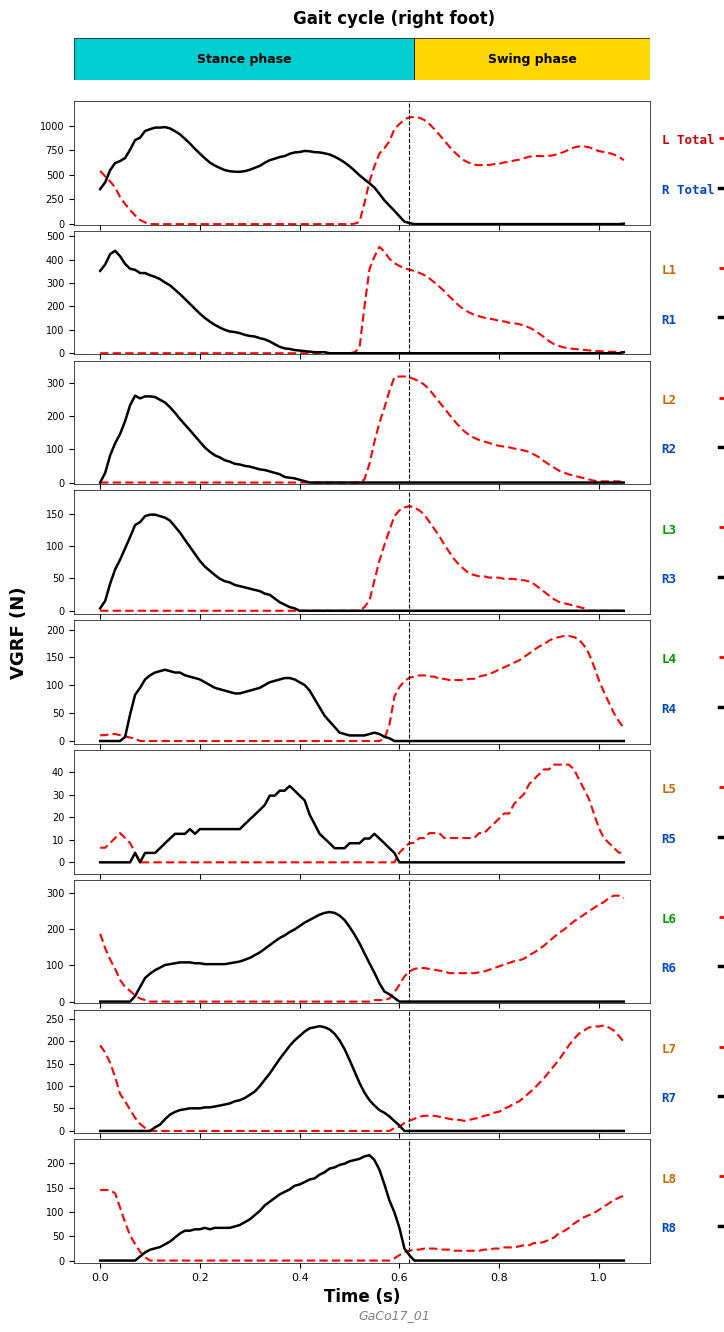

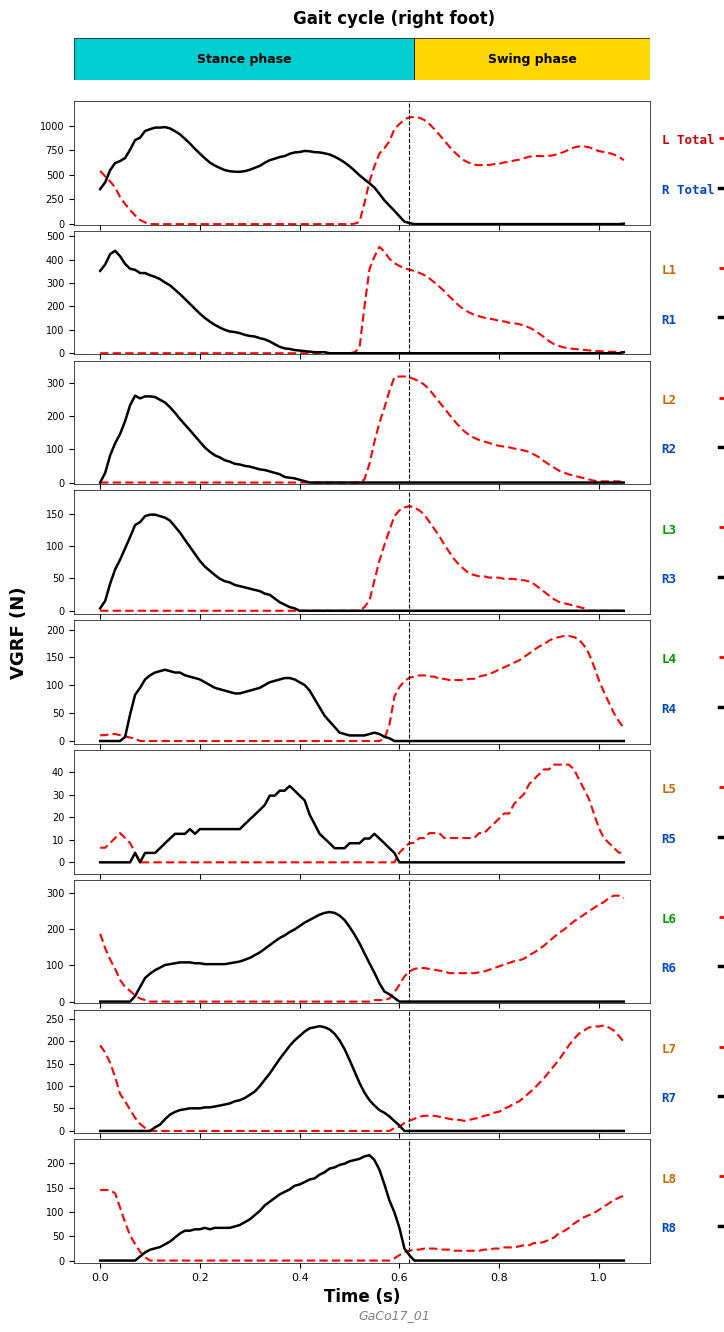

In [7]:
"""
VGRF Gait Cycle Visualization — PhysioNet PD Gait Dataset
=========================================================
Configure everything in main(). No CLI args needed.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# CONSTANTS
# ============================================================
FS = 100  # Sampling rate (Hz)
COLS_LEFT      = list(range(1, 9))    # L1–L8 (left foot sensors)
COLS_RIGHT     = list(range(9, 17))   # R1–R8 (right foot sensors)
COL_TOTAL_LEFT  = 17
COL_TOTAL_RIGHT = 18

# Sensor labels matching the foot diagram
LEFT_LABELS  = [f"L{i}" for i in range(1, 9)]   # L1 … L8
RIGHT_LABELS = [f"R{i}" for i in range(1, 9)]   # R1 … R8


# ============================================================
# GAIT CYCLE EXTRACTION
# ============================================================
def detect_heel_strikes(total_force, min_force=50, min_distance=60):
    contact = (total_force > min_force).astype(int)
    diff = np.diff(contact)
    strikes = np.where(diff == 1)[0] + 1

    if len(strikes) > 1:
        filtered = [strikes[0]]
        for s in strikes[1:]:
            if s - filtered[-1] >= min_distance:
                filtered.append(s)
        strikes = np.array(filtered)
    return strikes


def extract_gait_cycle(data, cycle_idx=0, foot='right'):
    col = COL_TOTAL_RIGHT if foot == 'right' else COL_TOTAL_LEFT
    strikes = detect_heel_strikes(data[:, col])

    if len(strikes) < cycle_idx + 2:
        raise ValueError(
            f"Only {len(strikes)-1} complete cycles found (requested {cycle_idx})."
        )

    start, end = strikes[cycle_idx], strikes[cycle_idx + 1]
    cycle_data = data[start:end]

    # Swing onset: where reference foot lifts off
    ref_force = cycle_data[:, col]
    contact_idx = np.where(ref_force > 20)[0]
    if len(contact_idx) > 0 and contact_idx[-1] + 1 < len(ref_force):
        swing_onset = contact_idx[-1] + 1
    else:
        mid = len(ref_force) // 2
        swing_onset = mid + np.argmin(ref_force[mid:])

    return cycle_data, swing_onset


# ============================================================
# VISUALIZATION
# ============================================================
def plot_gait_cycle(data, swing_onset, subject_id="Subject", save_path=None):
    n_samples  = len(data)
    time       = np.arange(n_samples) / FS
    swing_time = swing_onset / FS

    # Sensor pairs: (left_col, right_col, left_label, right_label)
    pairs = [(COL_TOTAL_LEFT, COL_TOTAL_RIGHT, "L Total", "R Total")]
    for i in range(8):
        pairs.append((COLS_LEFT[i], COLS_RIGHT[i],
                      LEFT_LABELS[i], RIGHT_LABELS[i]))

    n_rows = len(pairs)  # 9

    # Label colours
    left_colors  = ['#CC0000'] + ['#CC6600', '#CC6600', '#009900', '#009900',
                                   '#CC6600', '#009900', '#CC6600', '#CC6600']
    right_colors = ['#0044CC'] * 9

    # ── Figure ──────────────────────────────────────────────
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex=True,
                             gridspec_kw={'hspace': 0.05})
    fig.patch.set_facecolor('white')

    for idx, (ax, (lcol, rcol, llabel, rlabel)) in enumerate(zip(axes, pairs)):
        ax.set_facecolor('white')

        left_sig  = data[:, lcol]
        right_sig = data[:, rcol]

        # Left = red dashed, Right = black solid
        ax.plot(time, left_sig,  color='red',   linestyle='--',
                linewidth=1.5, dashes=(4, 2))
        ax.plot(time, right_sig, color='black', linestyle='-',
                linewidth=1.8)

        # Stance/Swing divider
        ax.axvline(x=swing_time, color='black', linestyle='--', linewidth=0.8)

        # Y-axis limits
        ymax = max(left_sig.max(), right_sig.max(), 1) * 1.15
        ax.set_ylim(-5, ymax)
        ax.tick_params(axis='y', labelsize=7, colors='black')
        ax.tick_params(axis='x', labelsize=8, colors='black')

        # Sensor labels on right
        ax.text(1.02, 0.65, llabel, transform=ax.transAxes,
                fontsize=9, fontweight='bold', color=left_colors[idx],
                family='monospace')
        ax.text(1.02, 0.25, rlabel, transform=ax.transAxes,
                fontsize=9, fontweight='bold', color=right_colors[idx],
                family='monospace')

        # Legend line markers beside labels
        ax.plot([1.12, 1.17], [0.70, 0.70], transform=ax.transAxes,
                color='red', linestyle='--', linewidth=2, dashes=(3, 2),
                clip_on=False)
        ax.plot([1.12, 1.17], [0.30, 0.30], transform=ax.transAxes,
                color='black', linestyle='-', linewidth=2.5,
                clip_on=False)

        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(0.5)
        ax.grid(False)

    # Common Y-axis label
    fig.text(0.02, 0.5, 'VGRF (N)', va='center', rotation='vertical',
             fontsize=13, fontweight='bold', color='black')

    axes[-1].set_xlabel('Time (s)', fontsize=12, fontweight='bold', color='black')

    # ── Layout — leave gap at top for the phase-bar header ──
    plt.subplots_adjust(left=0.10, right=0.82, top=0.88, bottom=0.05)

    # ── Dedicated phase-bar axes ─────────────────────────────
    # left=0.10, width = 0.82-0.10 = 0.72, sits just above top=0.88
    ax_header = fig.add_axes([0.10, 0.895, 0.72, 0.030])
    ax_header.set_xlim(0, 1)
    ax_header.set_ylim(0, 1)
    ax_header.axis('off')

    stance_frac = swing_time / time[-1]

    # Stance bar (cyan)
    ax_header.add_patch(plt.Rectangle(
        (0, 0), stance_frac, 1,
        facecolor='#00CED1', edgecolor='black', linewidth=0.5
    ))
    ax_header.text(
        stance_frac / 2, 0.5, 'Stance phase',
        ha='center', va='center',
        fontsize=9, fontweight='bold', color='black'
    )

    # Swing bar (yellow)
    ax_header.add_patch(plt.Rectangle(
        (stance_frac, 0), 1 - stance_frac, 1,
        facecolor='#FFD700', edgecolor='black', linewidth=0.5
    ))
    ax_header.text(
        (1 + stance_frac) / 2, 0.5, 'Swing phase',
        ha='center', va='center',
        fontsize=9, fontweight='bold', color='black'
    )

    # Title above the header bar
    fig.text(0.5, 0.935, 'Gait cycle (right foot)',
             ha='center', fontsize=12, fontweight='bold', color='black')

    # Subject ID watermark
    fig.text(0.5, 0.01, subject_id, ha='center', fontsize=9,
             color='gray', style='italic')

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f"Saved: {save_path}")

    plt.show()
    return fig


# ============================================================
# MAIN — EDIT YOUR SETTINGS HERE
# ============================================================

# ---- Settings (change these) ----
filepath    = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Gait_classification\gait_data\GaCo17_01.txt"
cycle_idx   = 2          # which gait cycle to extract
foot        = "right"    # reference foot: 'left' or 'right'
output_path = r"GaCo02_02_cycle2.png"

# ---- Load ----
data = pd.read_csv(filepath, sep='\t', header=None).values
subject_id = Path(filepath).stem
print(f"Loaded {subject_id}: {data.shape[0]} samples, {data.shape[1]} columns")

# ---- Extract gait cycle ----
cycle_data, swing_onset = extract_gait_cycle(data, cycle_idx=cycle_idx, foot=foot)
print(f"Cycle {cycle_idx}: {len(cycle_data)} samples "
      f"({len(cycle_data)/FS:.2f}s), swing onset at {swing_onset/FS:.2f}s")

# ---- Plot ----
plot_gait_cycle(cycle_data, swing_onset,
                subject_id=subject_id,
                save_path=output_path)